Name:- Dhokiya Jenil
Div :- A (IT)
Inroll :- 23SOEIT11003

Q-1 



In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
mobile = pd.read_csv("datasets/mobile.csv")

In [53]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              400 non-null    int64  
 1   EstimatedSalary  400 non-null    int64  
 2   Purchased        400 non-null    int64  
 3   norm_Age         400 non-null    float64
 4   norm_Salary      400 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 15.8 KB


In [54]:
mobile.describe()

,Age,EstimatedSalary,Purchased,norm_Age,norm_Salary
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500,0.467976,0.405500
std,10.482877,34096.960282,0.479864,0.249592,0.252570
min,18.000000,15000.000000,0.000000,0.000000,0.000000
25%,29.750000,43000.000000,0.000000,0.279762,0.207407
50%,37.000000,70000.000000,0.000000,0.452381,0.407407
75%,46.000000,88000.000000,1.000000,0.666667,0.540741
max,60.000000,150000.000000,1.000000,1.000000,1.000000


In [56]:
mobile.Purchased

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [7]:
mobile.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
print("num of row and col",mobile.shape)

muber (400, 3)


In [57]:
mobile.info


<bound method DataFrame.info of      Age  EstimatedSalary  Purchased  norm_Age  norm_Salary
0     19            19000          0  0.023810     0.029630
1     35            20000          0  0.404762     0.037037
2     26            43000          0  0.190476     0.207407
3     27            57000          0  0.214286     0.311111
4     19            76000          0  0.023810     0.451852
..   ...              ...        ...       ...          ...
395   46            41000          1  0.666667     0.192593
396   51            23000          1  0.785714     0.059259
397   50            20000          1  0.761905     0.037037
398   36            33000          0  0.428571     0.133333
399   49            36000          1  0.738095     0.155556

[400 rows x 5 columns]>

In [17]:
mobile.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [30]:
purchased_data = mobile[['Age','EstimatedSalary','Purchased']][mobile['Purchased']==1]
purchased_data

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [28]:
not_purchased_data = mobile[['Age','EstimatedSalary','Purchased']][mobile['Purchased']==0]
not_purchased_data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


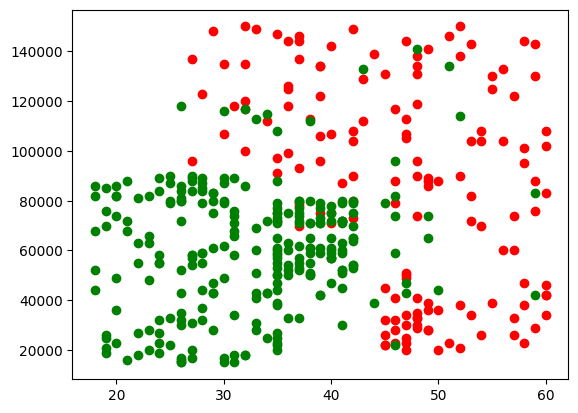

In [59]:
plt.scatter(purchased_data["Age"],purchased_data["EstimatedSalary"],c="red")
plt.scatter(not_purchased_data["Age"],not_purchased_data["EstimatedSalary"],c="green")

In [32]:
mobile['EstimatedSalary'].max()

np.int64(150000)

In [33]:
mobile['EstimatedSalary'].min()

np.int64(15000)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ['Age','EstimatedSalary']
scaled_values = scaler.fit_transform(mobile[features_to_scale])
mobile['nom_Age'] = scaled_values[:,0]
mobile['nom_Salary'] = scaled_values[:,1]

In [ ]:
from sklearn.model_selection import train_test_split
X = mobile[['nom_Age','nom_Salary']]
y=mobile['Purchased']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [37]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [38]:
model.score(X_train,y_train)*100

94.375

In [39]:
model.score(X_test,y_test)*100

85.0

Q2- computer

In [40]:
Q2_com = pd.read_csv("datasets/computers.csv")
Q2_com

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74
5,5,87
6,6,96
7,6,97
8,7,109
9,8,119


In [50]:
Q2_com.info

<bound method DataFrame.info of     Units  Minutes     Model0  Model1  Model2
0       1       23  97.214286      22      24
1       2       29  97.214286      34      42
2       3       49  97.214286      46      60
3       4       64  97.214286      58      78
4       4       74  97.214286      58      78
5       5       87  97.214286      70      96
6       6       96  97.214286      82     114
7       6       97  97.214286      82     114
8       7      109  97.214286      94     132
9       8      119  97.214286     106     150
10      9      149  97.214286     118     168
11      9      145  97.214286     118     168
12     10      154  97.214286     130     186
13     10      166  97.214286     130     186>

In [49]:
Q2_com.shape

(14, 5)

In [48]:
Q2_com.head

<bound method NDFrame.head of     Units  Minutes     Model0  Model1  Model2
0       1       23  97.214286      22      24
1       2       29  97.214286      34      42
2       3       49  97.214286      46      60
3       4       64  97.214286      58      78
4       4       74  97.214286      58      78
5       5       87  97.214286      70      96
6       6       96  97.214286      82     114
7       6       97  97.214286      82     114
8       7      109  97.214286      94     132
9       8      119  97.214286     106     150
10      9      149  97.214286     118     168
11      9      145  97.214286     118     168
12     10      154  97.214286     130     186
13     10      166  97.214286     130     186>

In [ ]:
Q2_com.describe()

,Units,Minutes
Units,1.000000,0.244757
Minutes,0.244757,1.000000


In [42]:
mean_value = Q2_com['Minutes'].mean()
print(mean_value)

97.21428571428571


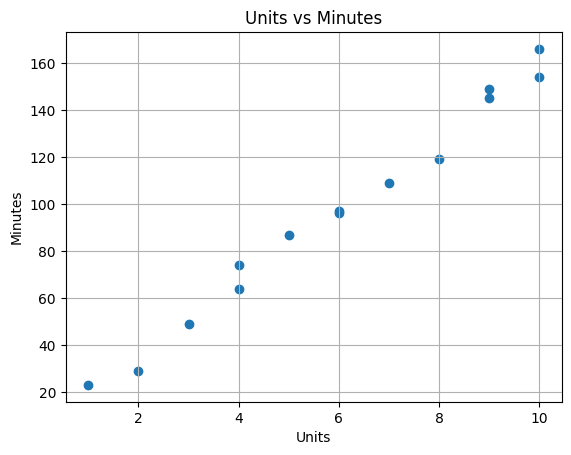

In [65]:
plt.scatter(Q2_com['Units'],Q2_com['Minutes'],colorizer='blue',marker='o')
plt.grid()
plt.title("Units vs Minutes")
plt.xlabel("Units")
plt.ylabel("Minutes")
plt.show()

In [44]:
Model0 = Q2_com['Minutes'].mean()
Model1 = 10 + 12 * Q2_com['Units']
Model2 = 6 + 18 * Q2_com['Units']

In [45]:
Q2_com['Model0'] = Model0
Q2_com['Model1'] = Model1
Q2_com['Model2'] = Model2

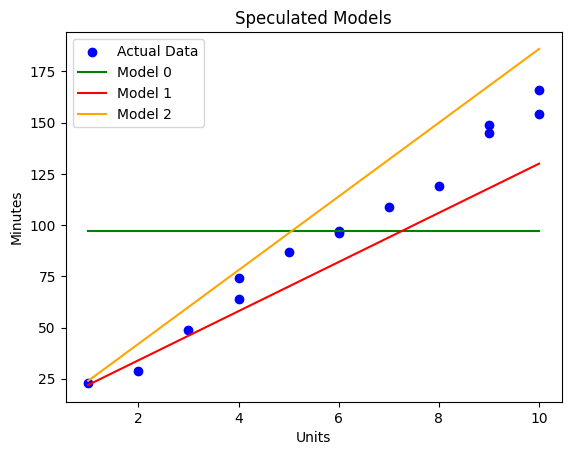

In [66]:
fig,ax = plt.subplots()
ax.scatter(Q2_com['Units'],Q2_com['Minutes'],color='blue',marker='o',label='Actual Data')
ax.plot(Q2_com['Units'],Q2_com['Model0'],color='green',label='Model 0')
ax.plot(Q2_com['Units'],Q2_com['Model1'],color='red',label='Model 1')
ax.plot(Q2_com['Units'],Q2_com['Model2'],color='orange',label='Model 2')
ax.set_xlabel("Units")
ax.set_ylabel("Minutes")
ax.set_title("Speculated Models")
ax.legend()